Project 658 – Resume Classification

Business objective - The document classification solution should significantly reduce the manual human effort in the HRM. It should achieve a higher level of accuracy and automation with minimal human intervention Sample Data Set Details: Resumes and financial documents.

In [1]:
##Importing the important libraries for EDA 

import os ##Impporting the OS library to work with files, folders and path 
import pandas as pd ##Importing the pandas library for files and data manipulation
import numpy as np ##Importing the Numpy library for data manipulation 

import re ##Importing the re package for data cleaning 
import nltk ##Importing the NLTK library for NLL functions 
from nltk.corpus import stopwords ##Importing this function to removing common words
from nltk.stem import WordNetLemmatizer ##Importing this function for lemmatization 

from docx import Document ##Importing this function to read .docx files 
import pdfplumber ##Importing this library to read pdf files and text 
import win32com.client ##This library is imported to interact with the windows OS

import logging ##Importing the logging function to track the errors 

##Defining the required functions 

In [2]:
##Text Preprocessing to remove stopwords, declaring custom stopwords, applying lemmatization and declaring leakage words  

nltk.download('stopwords') ##Downloading the stopwords from the nltk package 
nltk.download('wordnet') ##Using this for lemmatization to convert words to their root form 

stop_words = set(stopwords.words('english')) ##Loading the standard English Stopwords 

##Filtering the common words used in the reumes since these words are affecting the quality of text that's loading into the model 
custom_stopwords = {
    'name', 'resume', 'resumes', 'curriculum', 'vitae',
    'summary', 'objective', 'career', 'profile',
    'professional', 'experience', 'years', 'worked',
    'project', 'projects', 'role', 'responsible',
    'skills', 'team', 'client'
} 

stop_words.update(custom_stopwords) ##Adding the custom words to the main stopwords list

lemmatizer = WordNetLemmatizer() ##Converting the words to their root form 

##Filtering leakage words that hinders the model's performance and preventing overfitting. 
    #This is to reduce the error of misclassification based only on words such as sql 
leakage_words = [
    "peoplesoft", "workday", "sql", "developer",
    "lightning", "oracle", "hcm", "etl"
]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
##Defining the clean_text function used for preprocessing 
def clean_text(text):
    text = str(text).lower() ##This converts all strings to lower case 
    
    ##Removing the exact leakage words from the files 
    pattern = r'\b(' + '|'.join(leakage_words) + r')\b'
    text = re.sub(pattern, ' ', text)
    
    ##Removing URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    ##Removing all numerical and alphanumerical data from the files and retaining only alphabets
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    ##Removing extra space 
    text = re.sub(r'\s+', ' ', text).strip()

    ##Splitting sentances into words using the split function 
    words = text.split() 

    ##Removing the first 3 words which will be the name of the candidates which is not required to learn the model 
    if len(words) > 3: 
        words = words[3:]
    
    ##Removing noise from the files 
    words = [w for w in words if not re.match(r'^(.)\1+$', w)]
    
    ##Removing stopwords and short words from the files 
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    ##Removing junk or meaningless strings from the file 
    words = [w for w in words if not re.match(r'^[bcdfghjklmnpqrstvwxyz]{2,}$', w)]
    
    ##Lemmatization of the words in t
    words = [lemmatizer.lemmatize(w) for w in words]

    ##Joining the cleaned words into sentences 
    return " ".join(words) 

In [4]:
##Using the logging function to track the errors since the dataset is small 
logging.basicConfig(
    filename="resume_reader.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)


In [5]:
##Defining the read function for all the file formats 

##Function to read docx files and extract the whole document page by page and paragraph by paragraph 
def read_docx(path):
    try:
        doc = Document(path) ##path where the folder is located 
        return "\n".join([p.text for p in doc.paragraphs if p.text])
    except Exception as e:
        logging.error(f"DOCX ERROR: {path} - {e}")
        return ""

##Function to read pdf files and extract the whole document page by page and paragraph by paragraph 
def read_pdf(path):
    try:
        text = ""
        with pdfplumber.open(path) as pdf:
            for page in pdf.pages:
                text += page.extract_text() or ""
        return text
    except Exception as e:
        logging.error(f"PDF ERROR: {path} - {e}")
        return ""

##Function to read doc files and extract the whole document page by page and paragraph by paragraph 
def read_doc(path, word):
    try:
        doc = word.Documents.Open(path)
        text = doc.Content.Text
        doc.Close()
        return text
    except Exception as e:
        logging.error(f"DOC ERROR: {path} - {e}")
        return ""

In [6]:
##Defining functions to sort the resumes into the categories peoplesoft, workday, sql, react, reactjs and internship

def classify_resume(text):
    text = text.lower()

    ##Declaring a few keywords relevant to each category which will help in sorting the resumes 
    peoplesoft_keywords = [
        "peoplesoft", "peopletools", "sqr", "component interface",
        "application engine", "ps query"
    ]

    workday_keywords = [
        "workday", "workday hcm", "workday studio", "eib",
        "workday integration", "workday report"
    ]

    reactjs_keywords = [
        "reactjs", "redux", "jsx", "next.js"
    ]

    react_keywords = [
        "react"
    ]

    sql_keywords = [
        "plsql", "stored procedure", "oracle sql", "mysql", "database"
    ]

    internship_keywords = [
        "internship", "intern", "trainee"
    ]

    ##Using the conditional loop if to sort the resumes as per their categories 
    
    if any(word in text for word in peoplesoft_keywords):
        return "Peoplesoft"

    
    if any(word in text for word in workday_keywords):
        return "Workday"

    
    if any(word in text for word in reactjs_keywords):
        return "Reactjs"

    
    if "react" in text:
        return "React"

    
    if any(word in text for word in sql_keywords):
        return "SQL"

    return "Internship"

In [7]:
##Creating a function which combines all the previously defined functions which includes NLP functions and reading the files 

def load_data(data_path):
    texts = []
    categories = []
    file_names = []

    word = win32com.client.Dispatch("Word.Application")
    word.Visible = False

    total_files = 0
    success_files = 0

    for root, _, files in os.walk(data_path):
        for file in files:
            total_files += 1

            file_path = os.path.join(root, file)
            file_lower = file.lower()

            text = ""

            if file_lower.endswith(".docx"):
                text = read_docx(file_path)

            elif file_lower.endswith(".pdf"):
                text = read_pdf(file_path)

            elif file_lower.endswith(".doc"):
                text = read_doc(file_path, word)

            else:
                logging.warning(f"Unsupported file: {file_path}")
                continue

            if text.strip():
                cleaned = clean_text(text)
                category = classify_resume(cleaned)

                texts.append(cleaned)
                categories.append(category)
                file_names.append(file)

                success_files += 1
            else:
                logging.warning(f"EMPTY TEXT: {file_path}")

    word.Quit()

    ##Creating a dataframe with the loaded files which are sorted into their categories 
    df = pd.DataFrame({
        "File": file_names,
        "Resume": texts,
        "Category": categories
    })

    ##Priting the basic information of the loaded dataset 
    print("\nTotal files found:", total_files)
    print("Successfully processed:", success_files)
    print("Final dataset shape:", df.shape)

    print("\nCategory Distribution:\n", df["Category"].value_counts())

    return df


In [8]:
##Loading the dataset 
#path = r"C:\Users\arunr\Desktop\Data Science\Project\Resume Classification\P658_DATASET" ##Storing the path of the dataset 

main_folder = os.path.join(os.path.expanduser("~"), "Desktop", "P26", "Resumes")

df = load_data(main_folder) ##Running the load data function 


Total files found: 79
Successfully processed: 79
Final dataset shape: (79, 3)

Category Distribution:
 Category
Peoplesoft    22
SQL           18
Workday       14
Reactjs       13
React          9
Internship     3
Name: count, dtype: int64


In [9]:
##From the above output, we can see that there are a total of 79 files and the final shape of the dataset consists of 79 rows and 3 columns 

In [10]:
##Applying the clean_text function 
df["Resumes"] = df["Resume"].apply(clean_text)

In [11]:
##Loading the first few rows of the dataset tp ensure correctness 
df.head()

,File,Resume,Category,Resumes
0,Internship_Ravali_Musquare Technologies (1).docx,specialization computer science engg utilize t...,Internship,engg utilize technical achieving target develo...
1,Internship_Susovan Bag_Musquare Technologies.docx,challenging position field science technology ...,Internship,science technology utilize organization indivi...
2,React Developer_Deepakreddy.docx,secure position reputed organization efficient...,Reactjs,organization efficiently contribute knowledge ...
3,React Developer_Haripriya.docx,reactjs javascript phone gmail haripriyabattin...,Reactjs,gmail haripriyabattini gmai com location visak...
4,React Developer_Kamalakar Reddy.docx,linked development enterprise application web ...,Reactjs,application web applicationsrelated technology...


##EDA 

In [12]:
##Using the info() function to check the total entities and non null values in the dataset 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   File      79 non-null     object
 1   Resume    79 non-null     object
 2   Category  79 non-null     object
 3   Resumes   79 non-null     object
dtypes: object(4)
memory usage: 2.6+ KB


In [13]:
print("\nMissing Values:\n", df.isnull().sum()) ##Using the isnull function to get the total number of null values in the dataset 


Missing Values:
 File        0
Resume      0
Category    0
Resumes     0
dtype: int64


In [14]:
##From the above output, we can conclude that there are no missing values. 

In [15]:
##Checking how many entries are stored in each label 
df["Category"].value_counts()

Category
Peoplesoft    22
SQL           18
Workday       14
Reactjs       13
React          9
Internship     3
Name: count, dtype: int64

In [16]:
##The above output shows there are 22 files in peoplesoft, 18 in sql, 14 in workday, 13 in reactjs, 9 in react and 3 in internship

In [17]:
##Outliers detection based on length 
df["text_length"] = df["Resumes"].apply(lambda x: len(x.split())) ##Getting the length of the text in each file 

##Removing the outliers by finding the 1st and 3rd quantile 
q1 = df["text_length"].quantile(0.01)
q3 = df["text_length"].quantile(0.99)

##Creating a new dataframe after removing outliers that are resumes with short texts
df = df[(df["text_length"] > q1) & (df["text_length"] < q3)].copy() 

print("Outliers are handled")

Outliers are handled


In [18]:
##The above output confirms all outliers are handled using the quartile method 

##Visualizations 

In [19]:
##Importing the important libraries for creating visualizations 

import matplotlib.pyplot as plt ##Importing the matplotlib to create visualizations 
import seaborn as sns ##Importing the seaborn library to create advanced visualizations 

from wordcloud import WordCloud ##Importing the wordcloud library to create a wordcloud

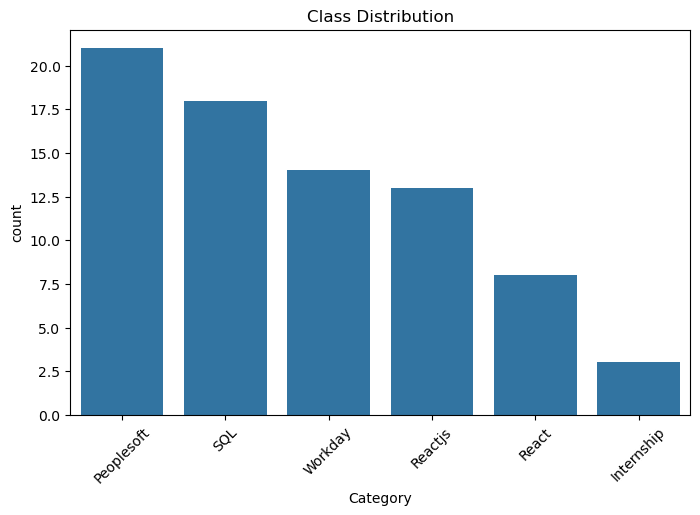

In [20]:
##Creating a visualization for class distribution 

plt.figure(figsize=(8,5)) ##Determing the figure size 
sns.countplot(x=df["Category"], order=df["Category"].value_counts().index) ##Creating a count plot 
plt.xticks(rotation=45) ##Rotating the x ticks to avoid overlapping 
plt.title("Class Distribution") ##Adding a title to the graph 
plt.show() ##Printing the graph 

In [21]:
##The above graph shows the distribution of how many files are present under each category
    #The distribution is uneven as all categories have different numbers of files. 

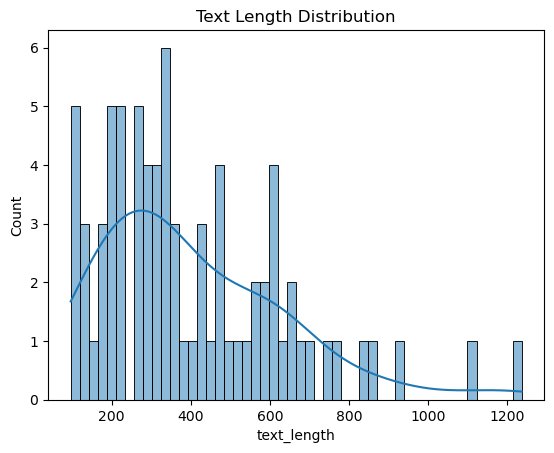

In [22]:
##Text Length Distribution 

sns.histplot(df["text_length"], bins=50, kde=True) ##Creating a dense plot 
plt.title("Text Length Distribution") ##Adding a title to the graph 
plt.show() ##Printing the graph 

In [23]:
##The above histogram shows the distribution of text length in the resumes 
    ##The histogram is left skewed 

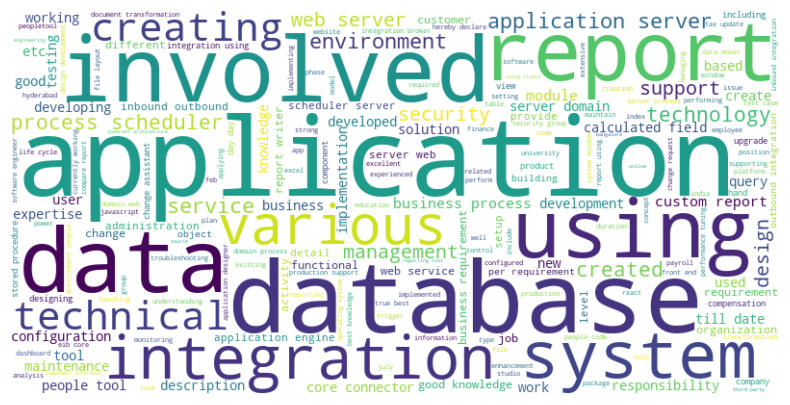

In [24]:
##Creating a word cloud to display the most frequent words that appeared in the dataset 
text = " ".join(df["Resumes"].dropna())

# remove empty strings
text = " ".join([t for t in df["Resumes"] if t.strip() != ""])


wc = WordCloud(width=800, height=400, background_color="white").generate(text) ##Creating a wordcloud with the cleaned text dataframe 
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear") ##Plotting the graph 
plt.axis("off") ##Naming the axis
plt.show() ##Printing the graph



In [25]:
##The above wordcloud shows the common words in the resumes like system, database, report, various, application, etc 

##Model building and Hyperparameter tuning 

In [26]:
##Importing the required library 

##Importing these functions for splitting the dataset into subsets for test and train, hperparameter tuning and cv score 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score 

from sklearn.pipeline import Pipeline ##Importing this function to implement a pipleline structure 

from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score ##Importing these functions for evaluation metrics 
from sklearn.feature_extraction.text import TfidfVectorizer ##Importing this function to TFIDF vertorizer 

from sklearn.linear_model import LogisticRegression ##Importing this function to create the logistic regression model 
from sklearn.svm import LinearSVC ##Importing this function to create the Linear SVM model 
from sklearn.naive_bayes import MultinomialNB ##Importing this function to create the Naive Bayes model 
from sklearn.neighbors import KNeighborsClassifier ##importing this function to create the KNN model 

from sklearn.preprocessing import Normalizer ##Importing this function to Normalize the data for building the KNN model 
 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay ##importing this function to create a confusion matrix 

import warnings
warnings.filterwarnings("ignore")

In [27]:
##Since there is a class imbalance, i.e reactjs, react and internship resumes are less in number, 
    #we will combine them under "others" to get a better model performance 
 
df["Category"] = df["Category"].replace({
    "React": "Other",
    "Reactjs": "Other",
    "Internship": "Other"
})

print("\nUpdated Category Distribution:\n", df["Category"].value_counts())


Updated Category Distribution:
 Category
Other         24
Peoplesoft    21
SQL           18
Workday       14
Name: count, dtype: int64


In [28]:
##Feature Engineering and test train split 

X = df['Resume'] ##Selecting the Resume column as the feature since the model learns with this data 
y = df['Category'] ##Selecting the Category column as the target column to predict the classification of the document 

##Splitting the dataset into subsets containing 30% Test data and 70% training data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
##Building the model 

##Determing the models by creating a dictionary 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000), ##Creating the logistic regression model 
    "Naive Bayes": MultinomialNB(), ##creating the Naive Bayes model 
    "Linear SVM": LinearSVC(), ##Creating the Linear SVM mocel 
    "KNN": KNeighborsClassifier(n_neighbors=5)  ##Using the KNN model with 5 clusters since we have a small dataset 
}

results = {} ##Storing the final accuracy results for the model 

##Using the for loop to iterate through each model 
for name, model in models.items():

    ##KNN needs normalization of data 
    if name == "KNN":
        pipeline = Pipeline([ ##creating a pipeline for KNN model 
            ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))), ##Performing TFIDF vectorization 
            ("norm", Normalizer()), ##Normalizing the dataset for balancing and fair learning 
            ("clf", model) 
        ])
    else: 
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))), ##Performing TFIDF vectorization 
            ("clf", model) ##Running the other models 
        ])

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5) ##Calculating and storing the CV score for each model 

    pipeline.fit(X_train, y_train) ##Training each model using the fit function 

    preds = pipeline.predict(X_test) ##Making predictions against the test data 

    acc = accuracy_score(y_test, preds) ##Calculating  the accuracy of the model 
    
    results[name] = acc ##Storing the accuracy of all models in a dictionary 

    ##Printing the outputs 
    print(f"\n{name}")
    print("Test Accuracy:", acc)
    print("CV Accuracy:", cv_scores.mean())
    print(classification_report(y_test, preds))


Logistic Regression
Test Accuracy: 0.8125
CV Accuracy: 0.8205128205128205
              precision    recall  f1-score   support

       Other       0.83      1.00      0.91         5
  Peoplesoft       0.75      0.75      0.75         4
         SQL       1.00      0.50      0.67         4
     Workday       0.75      1.00      0.86         3

    accuracy                           0.81        16
   macro avg       0.83      0.81      0.80        16
weighted avg       0.84      0.81      0.80        16


Naive Bayes
Test Accuracy: 0.8125
CV Accuracy: 0.7884615384615385
              precision    recall  f1-score   support

       Other       0.83      1.00      0.91         5
  Peoplesoft       0.75      0.75      0.75         4
         SQL       1.00      0.50      0.67         4
     Workday       0.75      1.00      0.86         3

    accuracy                           0.81        16
   macro avg       0.83      0.81      0.80        16
weighted avg       0.84      0.81      0.80

In [30]:
##The above output shows accuracy being repetative and not reliable. This is because the dataset is small

In [31]:
##Hyperparameter Tuning using Grid search 

##Passing parameters for each model 
param_grids = {
    "Logistic Regression": { ##Passing the parameters for the Logistic Regression Model 
        'tfidf__max_features': [3000, 5000], ##Determing the top N important words 
        'tfidf__ngram_range': [(1,1), (1,2)], ##Using unigrams and bigrams 
        'clf__C': [0.1, 1, 10] ##Determining more regularization 
    },
    
    "Naive Bayes": {
        'tfidf__max_features': [3000, 5000], ##Determing the top N important words
        'tfidf__ngram_range': [(1,1), (1,2)], ##Using unigrams and bigrams 
        'clf__alpha': [0.5, 1.0] ##Using the alpha parameter which will prevent 0 probability 
    },
    
    "Linear SVM": {
        'tfidf__max_features': [200, 300, 500], ##Determing the top N important words
        'tfidf__ngram_range': [(1,1)], ##Filtering only unigrams for a more reliable result 
        'tfidf__min_df': [2], ##Generalizing the model by removing words in less that 2 files 
        'tfidf__max_df': [0.8, 0.9], ##Removing the words that appears in the documents 
        'tfidf__stop_words': ['english'], ##Removing stopwords to reduce overfitting 
        'tfidf__sublinear_tf': [True], ##Preventing dominace of frequent words 

        'clf__C': [0.0001, 0.001, 0.01], ##Regularization of the model 
        'clf__loss': ['hinge'], ##Preventing data loss
        'clf__class_weight': [None, 'balanced'], ##Balancing the class 
        'clf__max_iter': [3000] ##Determining the number of ietrations 
    },
    
    "KNN": {
        'tfidf__max_features': [5000], ##Determing the max features to be trained 
        'tfidf__ngram_range': [(1,1)], ##Using unigrams 
        "clf__n_neighbors": [5, 7], ##Determining the number of clusters 
    }
}

results = {}  ##Creating a dictionary to store the results 
best_models = {} ##Creating a dictionary to store the best performing model

##Using the for loop to iterate all the models with the parameters 
for name, model in models.items():

    ##Performing TFIDF 
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", model)
    ])

    ##Performing GridSearch 
    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=1,
        verbose=0
    )

    ##Training the tuned data after hyperparameter tuning 
    grid.fit(X_train, y_train)

    ##Determining and storing the best model 
    best_model = grid.best_estimator_
    best_models[name] = best_model

    ##Making predictions against the test data for the tuned models 
    preds = best_model.predict(X_test)

    test_acc = accuracy_score(y_test, preds) ##Calculating the accuracy of each model 
    cv_score = grid.best_score_ ##Calculating the cv score of each model 

    results[name] = cv_score ##Storing the cv scores as the final deciding metrics since the dataset is small and accuracy is unreliable 

    ##Printing the results 
    print(f"\n{name} Results:")
    print("Test Accuracy:", test_acc)
    print("Best CV Score:", cv_score)
    print(classification_report(y_test, preds))


Logistic Regression Results:
Test Accuracy: 0.8125
Best CV Score: 0.885897435897436
              precision    recall  f1-score   support

       Other       0.83      1.00      0.91         5
  Peoplesoft       0.75      0.75      0.75         4
         SQL       1.00      0.50      0.67         4
     Workday       0.75      1.00      0.86         3

    accuracy                           0.81        16
   macro avg       0.83      0.81      0.80        16
weighted avg       0.84      0.81      0.80        16


Naive Bayes Results:
Test Accuracy: 0.75
Best CV Score: 0.8692307692307691
              precision    recall  f1-score   support

       Other       0.83      1.00      0.91         5
  Peoplesoft       0.67      0.50      0.57         4
         SQL       1.00      0.50      0.67         4
     Workday       0.60      1.00      0.75         3

    accuracy                           0.75        16
   macro avg       0.78      0.75      0.72        16
weighted avg       0.79 

In [32]:
##Since the dataset size is very small and contains only 79 files, we will consider CV score instead of accuracy. 
    #Accuracy is unreliable in this case due to the size of the dataset and the result is based only on the test set 
    #CV score is reliable since there are multiple folds and it gives an average and generalization performance

In [33]:
##Creating a table to compare the models 

rows = [] ##Creating a dictionary 

##Creating a for loop to iterate through all the models metrics and store the appropriate values 
for model, value in results.items(): 
    
    if isinstance(value, dict): ##Getting the scores from the dictionary if present 
        cv_score = value.get("cv_score") ##Storing the CV scores 
        test_acc = value.get("test_accuracy") ##Storing the accuracy scores
    
    else:
        cv_score = value
        test_acc = np.nan ##Adding null for accuracy since we are comparing the cv scores 

    ##Combining the model name, CV score and accuracy for each model 
    rows.append({
        "Model": model,
        "Best CV Score": cv_score,
        "Test Accuracy": test_acc
    })

##Convering the dictionary into a dataframe 
results_df = pd.DataFrame(rows)

##Sorting the dataframe in descending order to get the highest cv score on top 
results_df = results_df.sort_values(by="Best CV Score", ascending=False)

##Since the CV scores are mostly close to one, we will avoid rounding off 
results_df = results_df.round(3)

print("\nFinal Model Comparison:\n")
print(results_df)


Final Model Comparison:

                 Model  Best CV Score  Test Accuracy
0  Logistic Regression          0.886            NaN
1          Naive Bayes          0.869            NaN
3                  KNN          0.819            NaN
2           Linear SVM          0.723            NaN


In [34]:
##Saving the best model 

best_results = {} ##Creating a dictionary to store the best model 

##Using the for loop to iterate through all the model's metrics 
for model, value in results.items():
    if isinstance(value, dict):
        best_results[model] = value['cv_score'] ##Storing the best cv score 
    else:
        best_results[model] = value

best_model_name = max(best_results, key=best_results.get) ##Getting the best performing model's name

best_model = best_models[best_model_name] ##Storing the best performing model 

print("Best Model:", best_model_name, "is saved") ##Printing the best model 

Best Model: Logistic Regression is saved


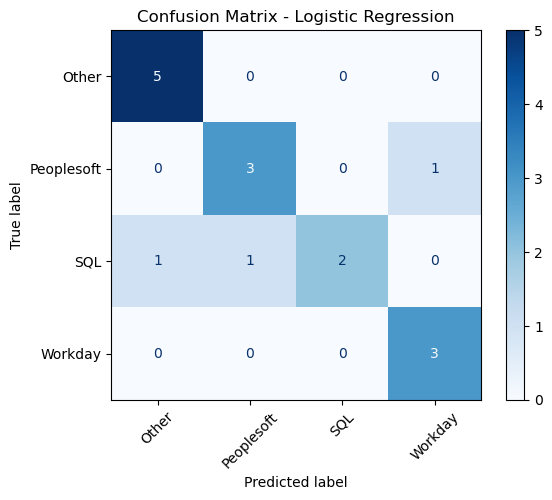

In [35]:
##Confusion Matric to check accuracy of prediction

y_pred = best_model.predict(X_test) ##Making predictions from the best model 

cm = confusion_matrix(y_test, y_pred) ##Calculating the confusion matrix table 

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
) ##Determing the parameters 

disp.plot(cmap="Blues") ##creating a visual for the confusion matrix 

plt.title(f"Confusion Matrix - {best_model_name}") ##Adding a title to the graph 
plt.xticks(rotation=45) ##Naming the x labels 
plt.show() ##Printing the graph

In [36]:
##The above confusion matrix shows the prediction range for the best model which is logistic regression in this case 

##Saving the model to deploy using streamlit 

In [37]:
import joblib ##Importing the joblib library to save the model 

joblib.dump(best_model, "resume_classifier.pkl") ##The best performing model is saved as a single pickle file 

['resume_classifier.pkl']